In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

In [2]:
info_df = pd.read_csv("/Users/kwagminseo/Documents/SAS/data/train/train_customer_info.csv")
targets_df = pd.read_csv("/Users/kwagminseo/Documents/SAS/data/train/train_targets.csv")
df = info_df.merge(targets_df, on='customer_id', how='left')

In [3]:
df.head()

,customer_id,join_date,age,gender,region_code,is_married,prefer_category,income_group,target_churn,target_ltv
0,C000001,2020-04-12,36,F,R03,1,Grocery,G4,0,556691.00
1,C000002,2021-03-11,32,F,R02,0,Home,G3,0,1460203.00
2,C000003,2022-05-10,41,M,R03,1,Fashion,G3,0,605476.00
3,C000004,2020-09-27,23,F,R02,1,Electronics,G3,0,1034150.00
4,C000006,2020-03-12,31,F,R04,0,Grocery,G3,1,76083.15


In [4]:
df.describe(include='all')

,customer_id,join_date,age,gender,region_code,is_married,prefer_category,income_group,target_churn,target_ltv
count,60000,60000,60000.000000,60000,60000,60000.000000,60000,60000,60000.000000,6.000000e+04
unique,60000,1000,NaN,2,7,NaN,5,5,NaN,NaN
top,C000001,2020-06-28,NaN,F,R05,NaN,Grocery,G2,NaN,NaN
freq,1,85,NaN,31180,8801,NaN,12136,18015,NaN,NaN
mean,NaN,NaN,35.780917,NaN,NaN,0.651067,NaN,NaN,0.098817,1.239290e+06
std,NaN,NaN,10.343592,NaN,NaN,0.476637,NaN,NaN,0.298418,1.360034e+06
min,NaN,NaN,19.000000,NaN,NaN,0.000000,NaN,NaN,0.000000,3.150000e+00
25%,NaN,NaN,28.000000,NaN,NaN,0.000000,NaN,NaN,0.000000,2.576475e+05
50%,NaN,NaN,35.000000,NaN,NaN,1.000000,NaN,NaN,0.000000,8.071545e+05
75%,NaN,NaN,43.000000,NaN,NaN,1.000000,NaN,NaN,0.000000,1.751954e+06


In [5]:
# 경과일 변수 추가
df['join_date'] = pd.to_datetime(df['join_date'])
base_date = pd.to_datetime('2023-12-31')
df['tenure_days'] = (base_date - df['join_date']).dt.days

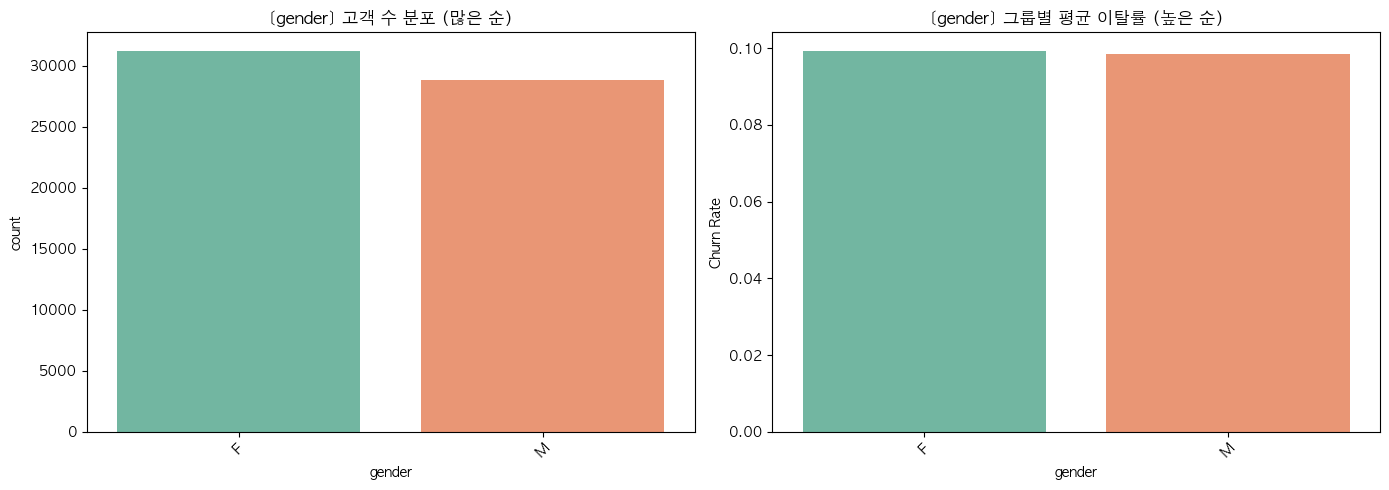

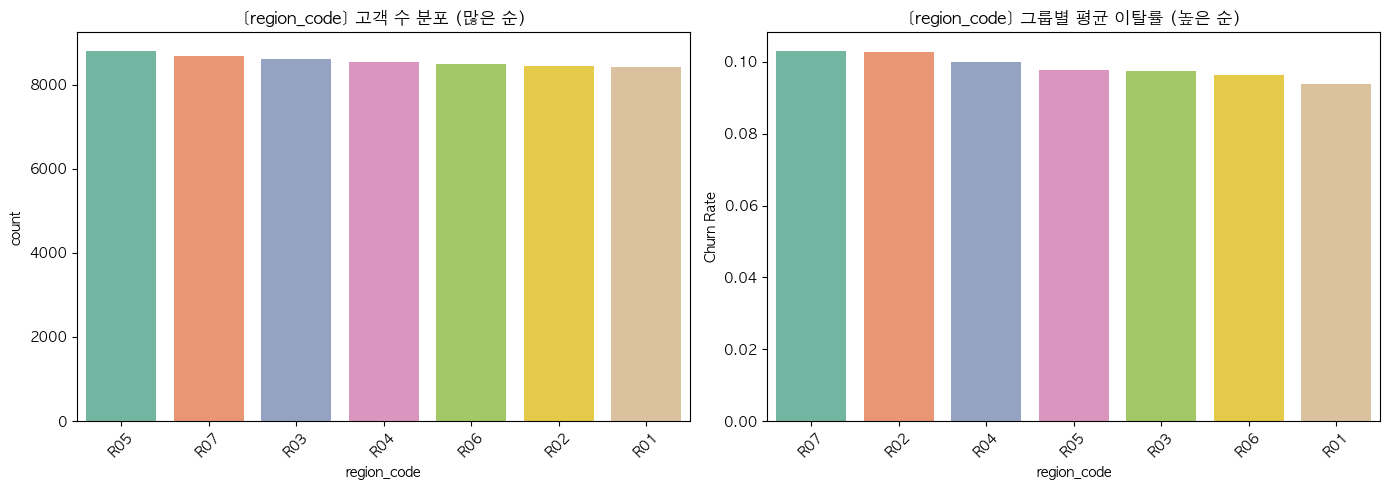

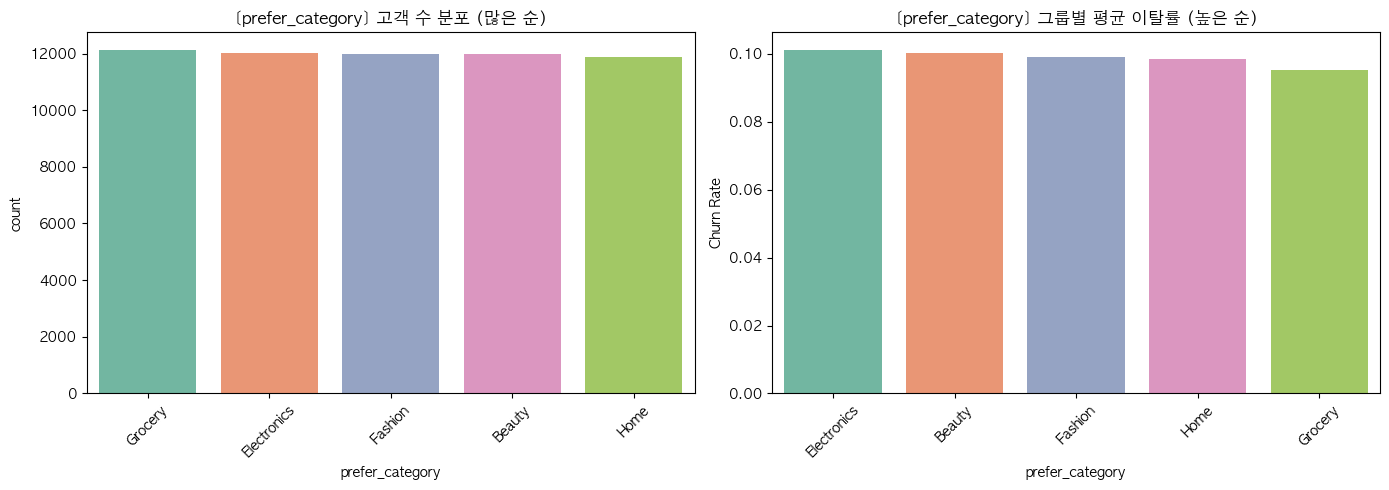

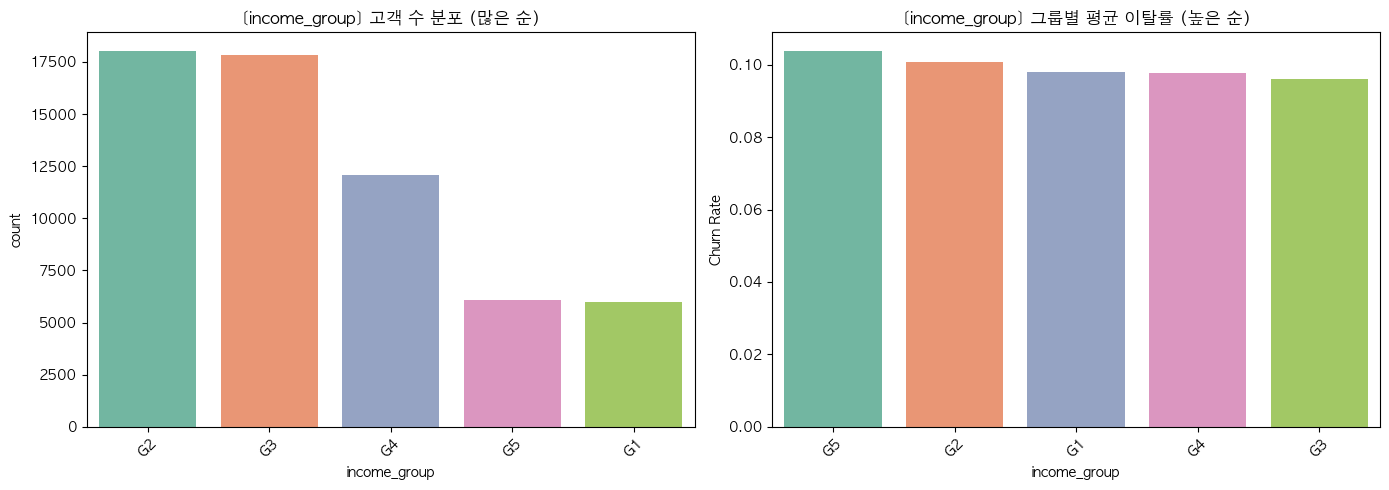

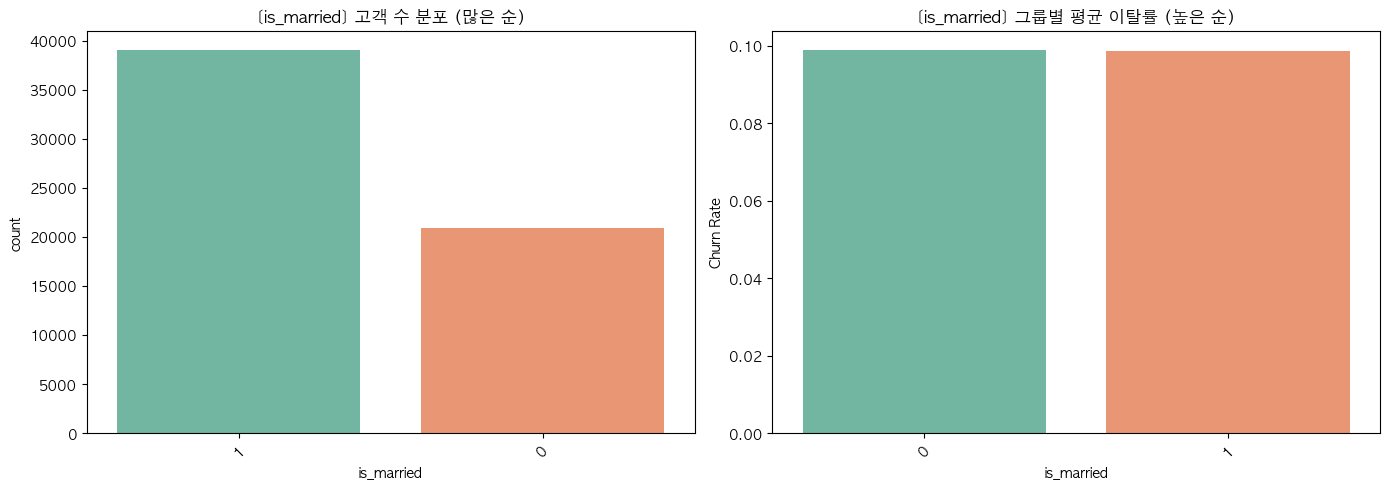

In [6]:
# ==========================================
# 범주형 변수 분포 및 이탈률(Churn) 분석
# ==========================================
cat_cols = ['gender', 'region_code', 'prefer_category', 'income_group', 'is_married']

# ==========================================
# 범주형 변수 분포 및 이탈률(Churn) 분석
# ==========================================
for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1) 빈도수 기준 정렬 인덱스 추출
    order_count = df[col].value_counts().index
    
    sns.countplot(data=df, x=col, ax=axes[0], palette='Set2', order=order_count)
    axes[0].set_title(f"[{col}] 고객 수 분포 (많은 순)")
    axes[0].tick_params(axis='x', rotation=45)
    
    # 2) 평균 이탈률 기준 정렬 인덱스 추출
    order_churn = df.groupby(col)['target_churn'].mean().sort_values(ascending=False).index
    
    sns.barplot(data=df, x=col, y='target_churn', ax=axes[1], palette='Set2', errorbar=None, order=order_churn)
    axes[1].set_title(f"[{col}] 그룹별 평균 이탈률 (높은 순)")
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].set_ylabel('Churn Rate')
    
    plt.tight_layout()
    plt.show()

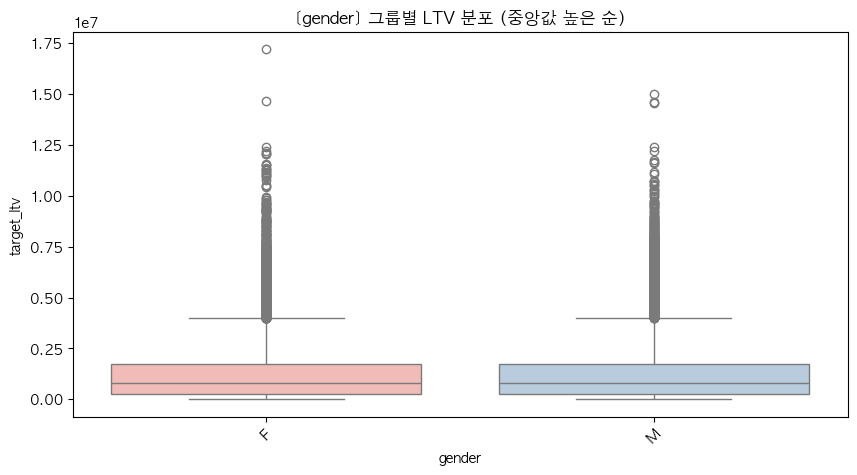

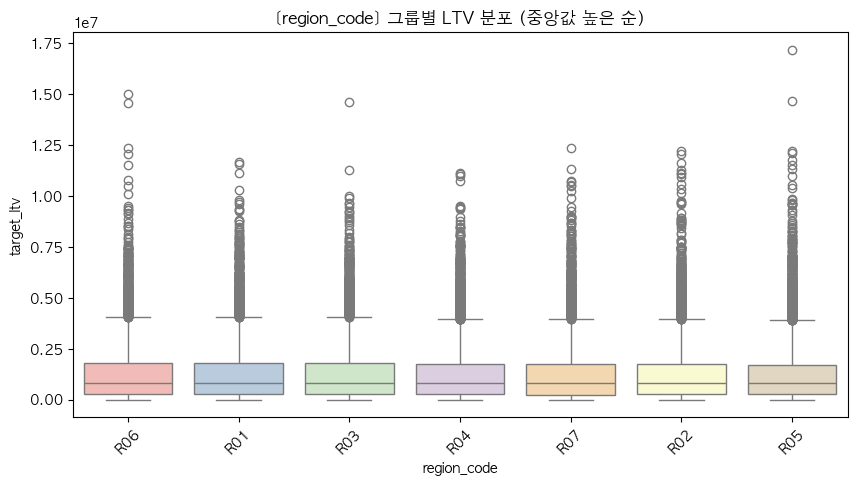

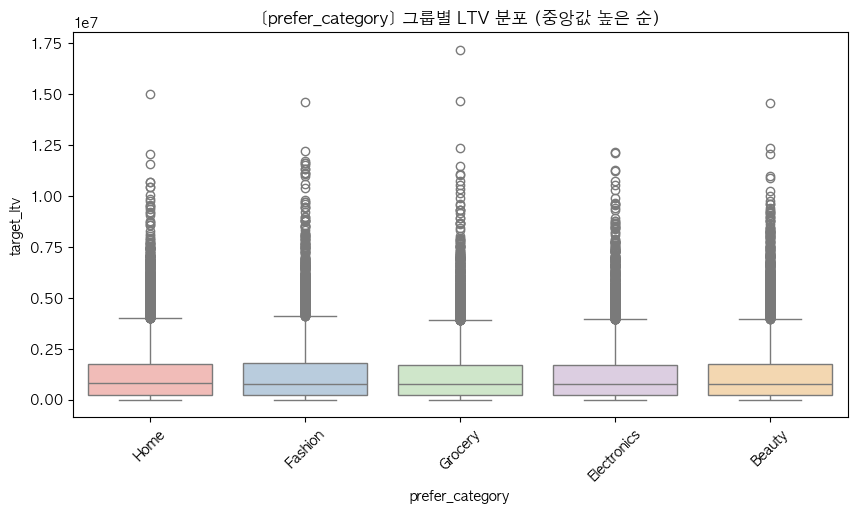

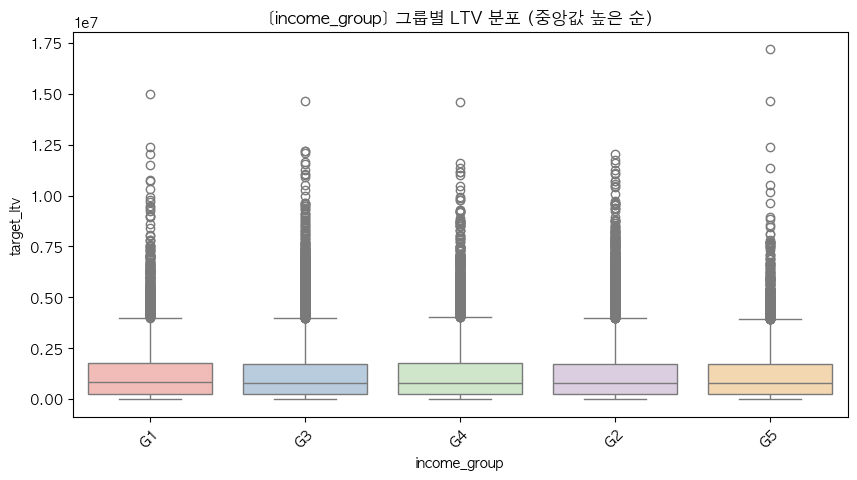

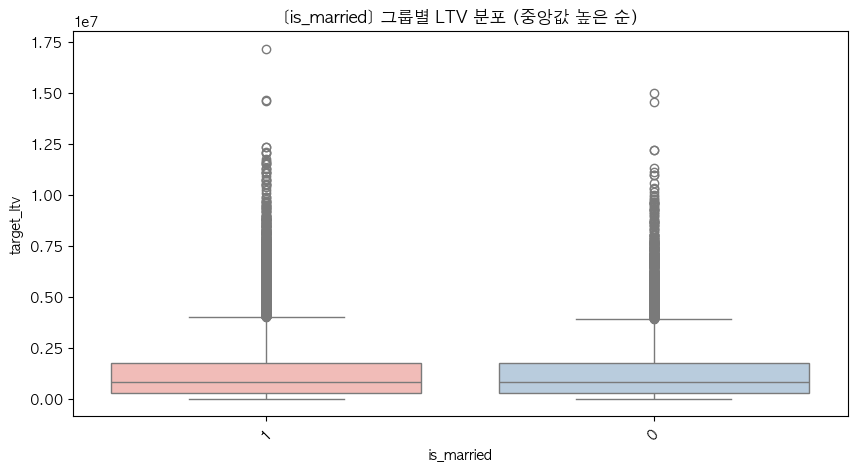

In [7]:
# ==========================================
# 범주형 변수별 LTV 분석 (정렬 추가)
# ==========================================
for col in cat_cols:
    plt.figure(figsize=(10, 5))
    
    # LTV 중앙값(Median) 기준 정렬 인덱스 추출
    order_ltv = df.groupby(col)['target_ltv'].median().sort_values(ascending=False).index
    
    sns.boxplot(data=df, x=col, y='target_ltv', palette='Pastel1', order=order_ltv)
    plt.title(f"[{col}] 그룹별 LTV 분포 (중앙값 높은 순)")
    plt.xticks(rotation=45)
    plt.show()

In [8]:
for col in cat_cols:
    print(f"\n{'='*50}")
    print(f" 📊 [{col}] 그룹별 수치 데이터 요약")
    print(f"{'='*50}")
    
    # 1. 그룹별로 묶어서 필요한 통계량 한 번에 계산
    summary = df.groupby(col).agg(
        고객수=('customer_id', 'count'),          # 빈도수
        이탈률=('target_churn', 'mean'),          # 평균 이탈률
        LTV_평균=('target_ltv', 'mean'),          # LTV 평균
        LTV_중앙값=('target_ltv', 'median')       # LTV 중앙값
    ).reset_index()
    
    # 2. 이탈률이 높은 순서대로 정렬 (원하는 기준에 따라 변경 가능)
    summary = summary.sort_values(by='이탈률', ascending=False)
    
    # 3. 주피터 노트북에서 보기 좋게 포맷팅하여 출력
    styled_summary = summary.style.format({
        '고객수': '{:,} 명',
        '이탈률': '{:.2%}',           # 소수점 둘째 자리까지 퍼센트로 표기
        'LTV_평균': '{:,.0f} 원',     # 천 단위 콤마 추가
        'LTV_중앙값': '{:,.0f} 원'
    }).hide(axis='index') # 불필요한 인덱스 번호 숨김
    
    display(styled_summary)


 📊 [gender] 그룹별 수치 데이터 요약


gender,고객수,이탈률,LTV_평균,LTV_중앙값
F,"31,180 명",9.91%,"1,231,946 원","807,859 원"
M,"28,820 명",9.85%,"1,247,235 원","805,610 원"



 📊 [region_code] 그룹별 수치 데이터 요약


region_code,고객수,이탈률,LTV_평균,LTV_중앙값
R07,"8,693 명",10.31%,"1,237,037 원","804,645 원"
R02,"8,450 명",10.27%,"1,223,526 원","797,884 원"
R04,"8,537 명",10.00%,"1,233,958 원","809,159 원"
R05,"8,801 명",9.78%,"1,228,584 원","792,085 원"
R03,"8,603 명",9.75%,"1,240,091 원","813,695 원"
R06,"8,500 명",9.65%,"1,256,658 원","821,104 원"
R01,"8,416 명",9.40%,"1,255,686 원","814,850 원"



 📊 [prefer_category] 그룹별 수치 데이터 요약


prefer_category,고객수,이탈률,LTV_평균,LTV_중앙값
Electronics,"12,016 명",10.12%,"1,227,127 원","804,020 원"
Beauty,"11,983 명",10.03%,"1,246,457 원","799,180 원"
Fashion,"11,991 명",9.90%,"1,248,582 원","806,600 원"
Home,"11,874 명",9.85%,"1,258,104 원","817,262 원"
Grocery,"12,136 명",9.51%,"1,216,666 원","805,836 원"



 📊 [income_group] 그룹별 수치 데이터 요약


income_group,고객수,이탈률,LTV_평균,LTV_중앙값
G5,"6,082 명",10.37%,"1,210,507 원","777,552 원"
G2,"18,015 명",10.09%,"1,231,911 원","797,244 원"
G1,"5,994 명",9.81%,"1,267,171 원","824,246 원"
G4,"12,060 명",9.77%,"1,249,125 원","806,094 원"
G3,"17,849 명",9.61%,"1,240,536 원","820,292 원"



 📊 [is_married] 그룹별 수치 데이터 요약


is_married,고객수,이탈률,LTV_평균,LTV_중앙값
0,"20,936 명",9.90%,"1,226,523 원","790,406 원"
1,"39,064 명",9.87%,"1,246,132 원","816,554 원"


In [9]:
# 1. 수치형 변수만 선택
num_cols = ['age', 'tenure_days']

# 2. describe() 함수로 기초 통계량 추출 후 보기 좋게 전치(T)
basic_stats = df[num_cols].describe().T

# 3. 컬럼명 한글로 변경 (선택 사항)
basic_stats.columns = ['고객 수(count)', '평균(mean)', '표준편차(std)', 
                       '최솟값(min)', '하위 25%(25%)', '중앙값(50%)', 
                       '상위 25%(75%)', '최댓값(max)']

# 4. 보기 좋게 포맷팅하여 출력 (소수점 1자리까지, 천단위 콤마)
styled_stats = basic_stats.style.format("{:,.1f}")\
                                .background_gradient(cmap='Blues', axis=1)

display(styled_stats)

,고객 수(count),평균(mean),표준편차(std),최솟값(min),하위 25%(25%),중앙값(50%),상위 25%(75%),최댓값(max)
age,"60,000.0",35.8,10.3,19.0,28.0,35.0,43.0,75.0
tenure_days,"60,000.0",959.3,289.2,461.0,707.0,958.0,"1,210.0","1,460.0"


In [10]:
from scipy.stats import pearsonr, pointbiserialr

print("="*60)
print(" ⚖️ [통계 검정] 나이(Age) 연속형 변수 상관분석 테스트")
print("="*60)

# --------------------------------------------------
# 1. 나이 vs 이탈(Churn) : 점 이분 상관분석 (Point-biserial)
# --------------------------------------------------
# 한 변수는 연속형(나이), 한 변수는 이진 범주형(이탈 0 or 1)일 때 사용합니다.
corr_pb, p_val_pb = pointbiserialr(df['target_churn'], df['age'])

print(f"▶️ [나이 vs 이탈(Churn)] 상관분석 결과")
print(f"  - 상관계수 (r): {corr_pb:.4f}")
print(f"  - p-value: {p_val_pb:.4e}")

if p_val_pb < 0.05:
    print("  👉 결론: 나이와 이탈 간에 통계적으로 유의미한 상관관계가 있습니다.\n")
else:
    print("  👉 결론: 나이와 이탈 간에 유의미한 선형 상관관계가 없습니다. (우연의 일치)\n")


# --------------------------------------------------
# 2. 나이 vs LTV : 피어슨 상관분석 (Pearson)
# --------------------------------------------------
# 두 변수 모두 연속형 수치일 때 사용합니다.
corr_r, p_val_corr = pearsonr(df['age'], df['target_ltv'])

print(f"▶️ [나이 vs 결제액(LTV)] Pearson 상관분석 결과")
print(f"  - 상관계수 (r): {corr_r:.4f}")
print(f"  - p-value: {p_val_corr:.4e}")

if p_val_corr < 0.05:
    print("  👉 결론: 나이와 LTV 간의 상관관계는 통계적으로 유의미합니다!")
    if corr_r > 0:
        print("     (나이가 많을수록 LTV가 높아지는 경향이 확실히 존재함)")
    else:
        print("     (나이가 많을수록 LTV가 낮아지는 경향이 확실히 존재함)")
else:
    print("  👉 결론: 나이와 LTV 사이에는 유의미한 선형 상관관계가 없습니다. (우연의 일치)")

 ⚖️ [통계 검정] 나이(Age) 연속형 변수 상관분석 테스트
▶️ [나이 vs 이탈(Churn)] 상관분석 결과
  - 상관계수 (r): 0.0052
  - p-value: 1.9862e-01
  👉 결론: 나이와 이탈 간에 유의미한 선형 상관관계가 없습니다. (우연의 일치)

▶️ [나이 vs 결제액(LTV)] Pearson 상관분석 결과
  - 상관계수 (r): 0.0292
  - p-value: 8.9319e-13
  👉 결론: 나이와 LTV 간의 상관관계는 통계적으로 유의미합니다!
     (나이가 많을수록 LTV가 높아지는 경향이 확실히 존재함)


In [11]:
# ==========================================
# 나이(Age) 구간화 및 시니어 타겟 분석
# ==========================================
print("\n" + "="*60)
print(" 📊 [1] 연령대별 고객 분석: '60대 이상 시니어층의 양면성'")
print("="*60)

# 나이 구간(Binning) 설정
bins_age = [0, 19, 29, 39, 49, 59, 100]
labels_age = ['10대', '20대', '30대', '40대', '50대', '60대 이상']
df['age_group'] = pd.cut(df['age'], bins=bins_age, labels=labels_age)

# 연령대별 통계량 계산
age_summary = df.groupby('age_group').agg(
    고객수=('customer_id', 'count'),
    이탈률=('target_churn', 'mean'),
    LTV_평균=('target_ltv', 'mean')
).reset_index()

# 깔끔하게 포맷팅하여 표 출력
styled_age = age_summary.style.format({
    '고객수': '{:,} 명',
    '이탈률': '{:.2%}',
    'LTV_평균': '{:,.0f} 원'
}).hide(axis='index').background_gradient(subset=['이탈률', 'LTV_평균'], cmap='Reds')
display(styled_age)


 📊 [1] 연령대별 고객 분석: '60대 이상 시니어층의 양면성'


age_group,고객수,이탈률,LTV_평균
10대,"4,382 명",9.97%,"1,194,130 원"
20대,"13,170 명",9.75%,"1,202,919 원"
30대,"21,155 명",9.74%,"1,238,231 원"
40대,"15,272 명",10.06%,"1,249,838 원"
50대,"5,170 명",10.04%,"1,313,334 원"
60대 이상,851 명,10.81%,"1,421,881 원"


In [12]:
# ==========================================
# 2. 가입 경과일(Tenure) 구간화 및 충성 고객 이탈 분석
# ==========================================
print("\n" + "="*60)
print(" 📊 [2] 가입 기간별 고객 분석: '1년 차와 장기 고인물 고객의 이탈'")
print("="*60)

# 가입 경과일을 4등분(Quartile) 하여 충성도(고인물) 그룹 생성
# (전체 최소 가입일이 461일이므로 이미 전원 장기 고객임)
df['tenure_group'] = pd.qcut(df['tenure_days'], q=4, 
                             labels=['Q1 (비교적 최근)', 'Q2 (적응기)', 'Q3 (안정기)', 'Q4 (초장기 찐고객)'])

# 가입 기간 그룹별 통계량 계산
tenure_summary = df.groupby('tenure_group').agg(
    고객수=('customer_id', 'count'),
    평균가입일=('tenure_days', 'mean'),
    이탈률=('target_churn', 'mean'),
    LTV_평균=('target_ltv', 'mean')
).reset_index()

# 깔끔하게 포맷팅하여 표 출력
styled_tenure = tenure_summary.style.format({
    '고객수': '{:,} 명',
    '평균가입일': '{:.0f} 일',
    '이탈률': '{:.2%}',
    'LTV_평균': '{:,.0f} 원'
}).hide(axis='index').background_gradient(subset=['이탈률', 'LTV_평균'], cmap='Blues')
display(styled_tenure)


 📊 [2] 가입 기간별 고객 분석: '1년 차와 장기 고인물 고객의 이탈'


tenure_group,고객수,평균가입일,이탈률,LTV_평균
Q1 (비교적 최근),"15,030 명",584 일,9.96%,"1,246,023 원"
Q2 (적응기),"15,001 명",834 일,9.80%,"1,236,505 원"
Q3 (안정기),"15,021 명",1086 일,9.68%,"1,241,287 원"
Q4 (초장기 찐고객),"14,948 명",1335 일,10.09%,"1,233,306 원"


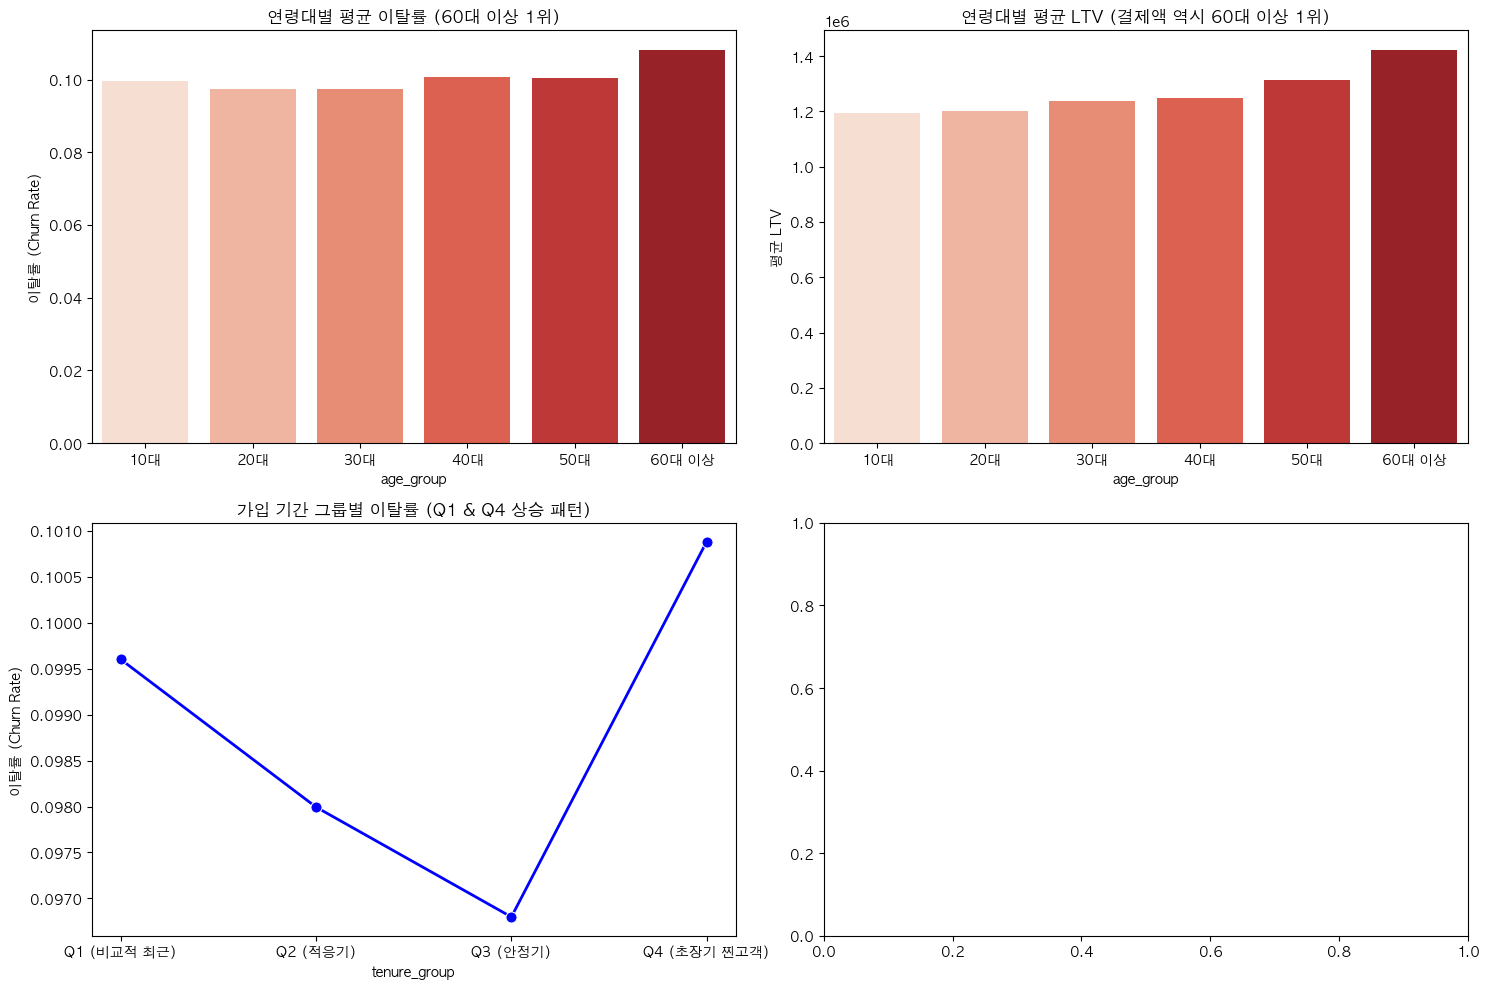

In [13]:
# ==========================================
# 3. 핵심 인사이트 시각화 (보고서 캡처용)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1) 연령대별 이탈률 (Barplot)
sns.barplot(data=df, x='age_group', y='target_churn', ax=axes[0, 0], palette='Reds', errorbar=None)
axes[0, 0].set_title("연령대별 평균 이탈률 (60대 이상 1위)")
axes[0, 0].set_ylabel("이탈률 (Churn Rate)")

# 2) 연령대별 LTV 평균 (Barplot)
sns.barplot(data=df, x='age_group', y='target_ltv', ax=axes[0, 1], palette='Reds', errorbar=None)
axes[0, 1].set_title("연령대별 평균 LTV (결제액 역시 60대 이상 1위)")
axes[0, 1].set_ylabel("평균 LTV")

# 3) 가입 기간 그룹별 이탈률 (Lineplot으로 U자 형태 강조)
sns.lineplot(data=tenure_summary, x='tenure_group', y='이탈률', ax=axes[1, 0], marker='o', color='blue', linewidth=2, markersize=8)
axes[1, 0].set_title("가입 기간 그룹별 이탈률 (Q1 & Q4 상승 패턴)")
axes[1, 0].set_ylabel("이탈률 (Churn Rate)")

plt.tight_layout()
plt.show()

 📊 [다변량 분석] 평균(Mean) vs 중앙값(Median) 나란히 비교하기


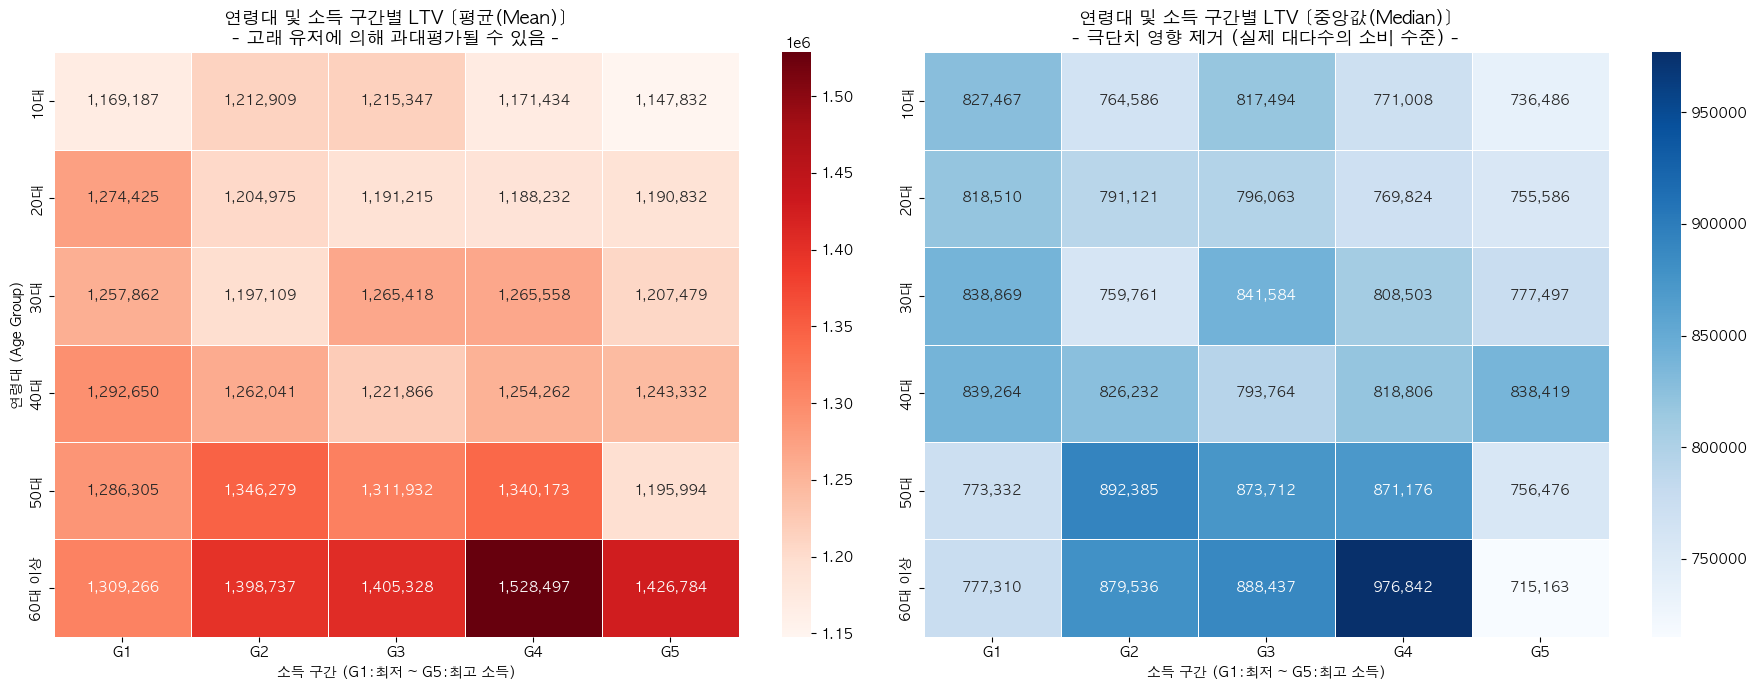

In [14]:
print("="*70)
print(" 📊 [다변량 분석] 평균(Mean) vs 중앙값(Median) 나란히 비교하기")
print("="*70)

# --------------------------------------------------
# 1. 피벗 테이블 2개 생성 (평균 vs 중앙값)
# --------------------------------------------------
pivot_mean = df.pivot_table(index='age_group', columns='income_group', values='target_ltv', aggfunc='mean')
pivot_median = df.pivot_table(index='age_group', columns='income_group', values='target_ltv', aggfunc='median')

# --------------------------------------------------
# 2. 시각화 (두 개의 히트맵 나란히 비교)
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# [왼쪽] 평균 히트맵 (극단치의 영향을 받은 상태)
sns.heatmap(pivot_mean, annot=True, fmt=",.0f", cmap="Reds", linewidths=.5, ax=axes[0])
axes[0].set_title("연령대 및 소득 구간별 LTV [평균(Mean)]\n- 고래 유저에 의해 과대평가될 수 있음 -", fontsize=13)
axes[0].set_ylabel("연령대 (Age Group)")
axes[0].set_xlabel("소득 구간 (G1:최저 ~ G5:최고 소득)")

# [오른쪽] 중앙값 히트맵 (일반적인 고객의 상태)
sns.heatmap(pivot_median, annot=True, fmt=",.0f", cmap="Blues", linewidths=.5, ax=axes[1])
axes[1].set_title("연령대 및 소득 구간별 LTV [중앙값(Median)]\n- 극단치 영향 제거 (실제 대다수의 소비 수준) -", fontsize=13)
axes[1].set_ylabel("") # y축 라벨 생략 (왼쪽과 동일하므로)
axes[1].set_xlabel("소득 구간 (G1:최저 ~ G5:최고 소득)")

plt.tight_layout()
plt.show()

In [15]:
# 2. 연령대 & 소득 구간별 통합 통계량 계산
# target_churn의 평균(mean)은 곧 이탈률(%)이 됩니다.
analysis_df = df.groupby(['age_group', 'income_group']).agg(
    고객수=('customer_id', 'count'),
    이탈률=('target_churn', 'mean'),
    LTV_평균=('target_ltv', 'mean'),
    LTV_중앙값=('target_ltv', 'median')
).reset_index()

# 3. 분석을 돕기 위한 추가 지표: 평균과 중앙값의 차이(Gap)
# 이 수치가 클수록 해당 그룹에 '초고액 결제자(고래 유저)'가 많이 숨어있다는 뜻입니다.
analysis_df['LTV_Gap(평균-중앙값)'] = analysis_df['LTV_평균'] - analysis_df['LTV_중앙값']

# 4. 보기 좋게 정렬 (예: LTV 중앙값 높은 순)
analysis_df = analysis_df.sort_values(by='LTV_중앙값', ascending=False)

# 5. 스타일링 (이탈률은 빨간색, LTV는 파란색 계열로 강조)
styled_df = analysis_df.style.format({
    '고객수': '{:,}명',
    '이탈률': '{:.2%}',
    'LTV_평균': '{:,.0f}원',
    'LTV_중앙값': '{:,.0f}원',
    'LTV_Gap(평균-중앙값)': '{:,.0f}원'
}).background_gradient(subset=['이탈률'], cmap='Reds') \
  .background_gradient(subset=['LTV_중앙값'], cmap='Blues') \
  .background_gradient(subset=['LTV_Gap(평균-중앙값)'], cmap='Purples')

# 주피터 노트북에서 출력
display(styled_df)

# 필요 시 CSV로 저장하여 팀원들에게 공유
# analysis_df.to_csv("age_income_comprehensive_analysis.csv", index=False)

,age_group,income_group,고객수,이탈률,LTV_평균,LTV_중앙값,LTV_Gap(평균-중앙값)
28,60대 이상,G4,170명,10.00%,"1,528,497원","976,842원","551,655원"
21,50대,G2,"1,507명",9.69%,"1,346,279원","892,385원","453,894원"
27,60대 이상,G3,257명,10.12%,"1,405,328원","888,437원","516,891원"
26,60대 이상,G2,267명,11.99%,"1,398,737원","879,536원","519,201원"
22,50대,G3,"1,574명",9.59%,"1,311,932원","873,712원","438,220원"
23,50대,G4,"1,041명",10.66%,"1,340,173원","871,176원","468,997원"
12,30대,G3,"6,258명",8.96%,"1,265,418원","841,584원","423,833원"
15,40대,G1,"1,580명",9.62%,"1,292,650원","839,264원","453,386원"
10,30대,G1,"2,091명",9.18%,"1,257,862원","838,869원","418,993원"
19,40대,G5,"1,519명",9.35%,"1,243,332원","838,419원","404,913원"


 🚨 [다변량 분석] 이탈률(Churn Rate) 집중 탐구


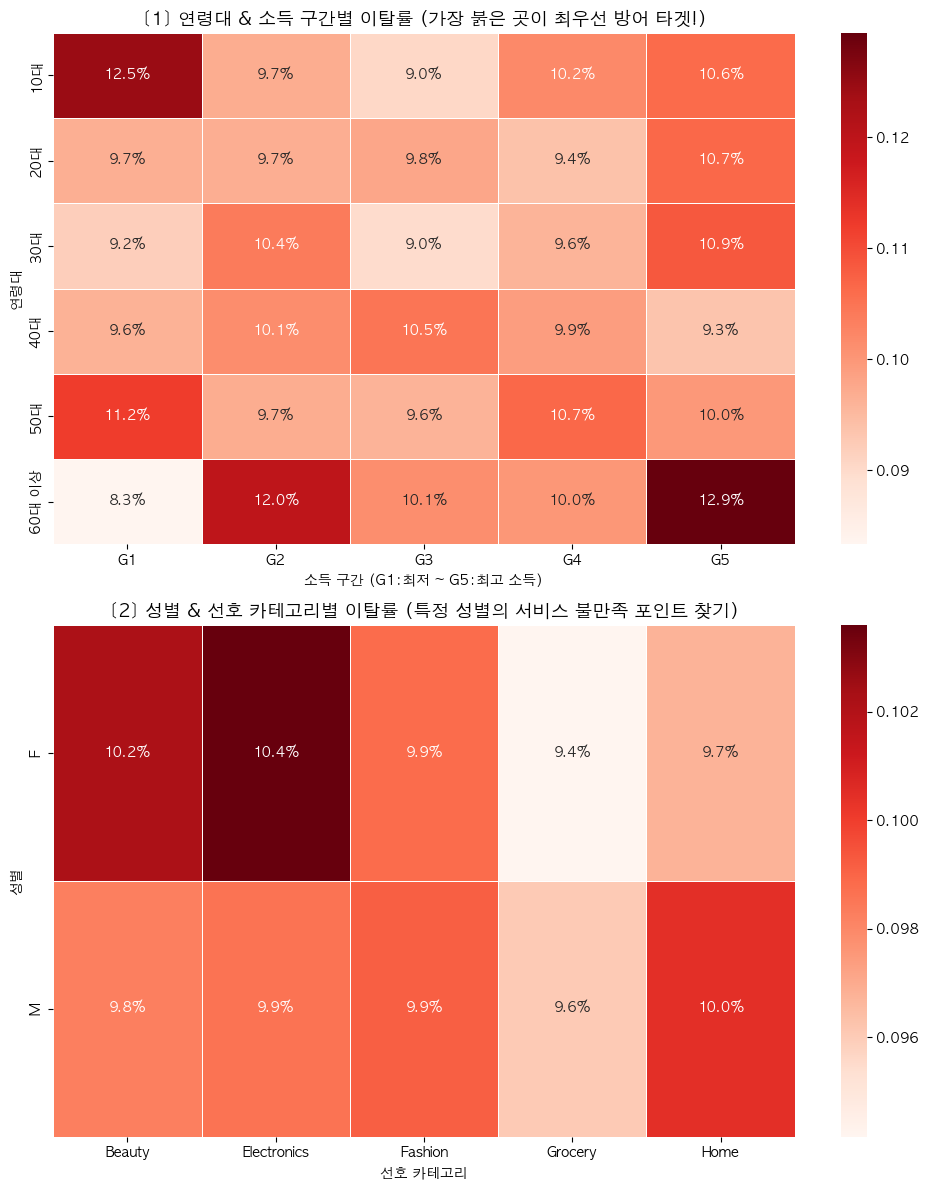

In [16]:
print("="*60)
print(" 🚨 [다변량 분석] 이탈률(Churn Rate) 집중 탐구")
print("="*60)

fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# --------------------------------------------------
# 1. 연령대 x 소득 구간별 이탈률 (Age Group x Income)
# --------------------------------------------------
# 이탈 여부(0, 1)의 평균(mean)을 구하면 이탈률(%)이 됩니다.
pivot_age_income = df.pivot_table(index='age_group', columns='income_group', values='target_churn', aggfunc='mean')

# 색상이 붉을수록 이탈률이 높은(위험한) 타겟층입니다.
sns.heatmap(pivot_age_income, annot=True, fmt=".1%", cmap="Reds", linewidths=.5, ax=axes[0])
axes[0].set_title("[1] 연령대 & 소득 구간별 이탈률 (가장 붉은 곳이 최우선 방어 타겟!)", fontsize=13)
axes[0].set_ylabel("연령대")
axes[0].set_xlabel("소득 구간 (G1:최저 ~ G5:최고 소득)")

# --------------------------------------------------
# 2. 성별 x 선호 카테고리별 이탈률 (Gender x Category)
# --------------------------------------------------
pivot_gender_cat = df.pivot_table(index='gender', columns='prefer_category', values='target_churn', aggfunc='mean')

sns.heatmap(pivot_gender_cat, annot=True, fmt=".1%", cmap="Reds", linewidths=.5, ax=axes[1])
axes[1].set_title("[2] 성별 & 선호 카테고리별 이탈률 (특정 성별의 서비스 불만족 포인트 찾기)", fontsize=13)
axes[1].set_ylabel("성별")
axes[1].set_xlabel("선호 카테고리")

plt.tight_layout()
plt.show()

 👨‍👩‍👧‍👦 [라이프 스테이지 심층 분석] 평균 vs 중앙값 LTV 비교


age_group,결혼상태,고객수,이탈률,LTV_평균,LTV_중앙값,차이(Mean - Median)
60대 이상,기혼,557 명,10.95%,"1,454,537 원","908,602 원","545,935 원"
50대,미혼,"1,804 명",9.42%,"1,338,124 원","866,537 원","471,587 원"
50대,기혼,"3,366 명",10.37%,"1,300,049 원","850,032 원","450,017 원"
40대,기혼,"9,925 명",10.21%,"1,262,665 원","825,777 원","436,888 원"
30대,기혼,"13,821 명",9.78%,"1,239,695 원","816,119 원","423,576 원"
10대,기혼,"2,855 명",9.63%,"1,195,358 원","812,187 원","383,171 원"
60대 이상,미혼,294 명,10.54%,"1,360,012 원","807,881 원","552,131 원"
40대,미혼,"5,347 명",9.80%,"1,226,028 원","801,544 원","424,484 원"
20대,기혼,"8,540 명",9.44%,"1,219,464 원","793,960 원","425,504 원"
30대,미혼,"7,334 명",9.65%,"1,235,471 원","789,164 원","446,307 원"


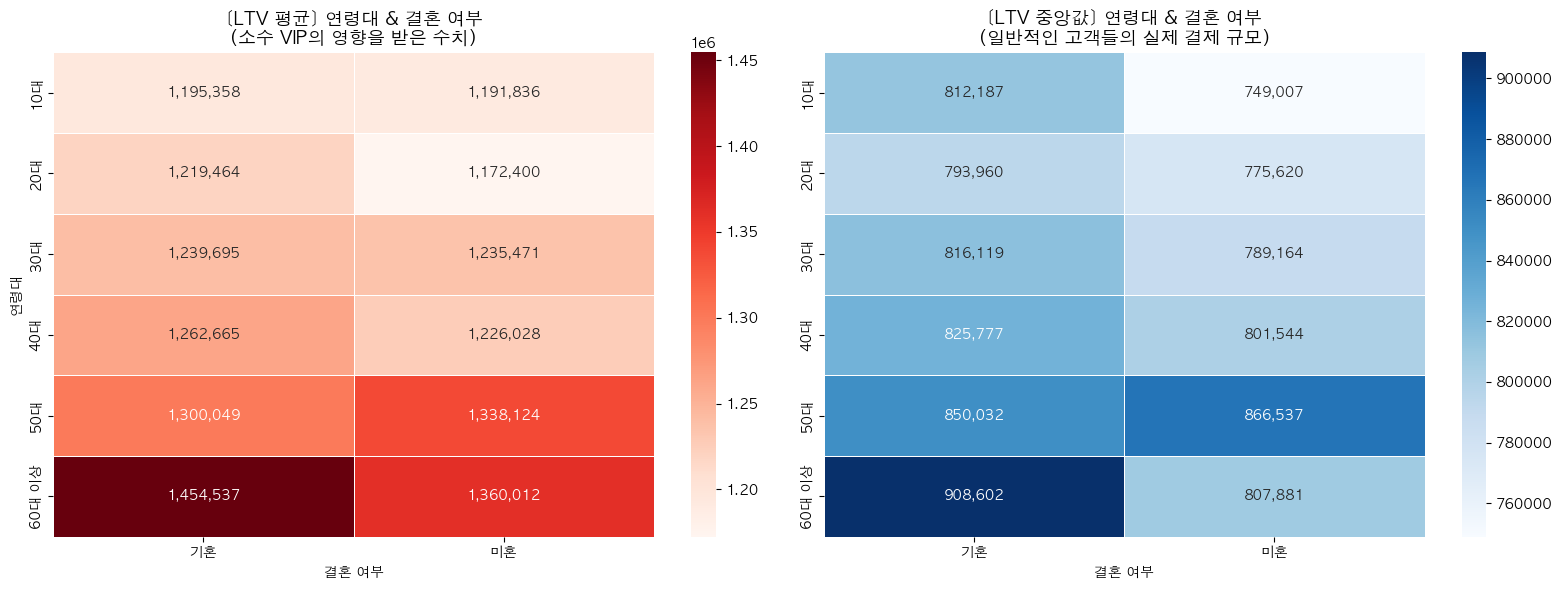

In [17]:
print("="*70)
print(" 👨‍👩‍👧‍👦 [라이프 스테이지 심층 분석] 평균 vs 중앙값 LTV 비교")
print("="*70)

# 1. 'age_group' 및 '결혼상태' 파생 변수 확인 및 생성
bins_age = [0, 19, 29, 39, 49, 59, 100]
labels_age = ['10대', '20대', '30대', '40대', '50대', '60대 이상']
if 'age_group' not in df.columns:
    df['age_group'] = pd.cut(df['age'], bins=bins_age, labels=labels_age)

if '결혼상태' not in df.columns:
    df['결혼상태'] = np.where(df['is_married'] == 1, '기혼', '미혼')

# --------------------------------------------------
# 1. 통계 요약표 (평균, 중앙값, 그리고 그 차이 계산)
# --------------------------------------------------
life_summary = df.groupby(['age_group', '결혼상태']).agg(
    고객수=('customer_id', 'count'),
    이탈률=('target_churn', 'mean'),
    LTV_평균=('target_ltv', 'mean'),
    LTV_중앙값=('target_ltv', 'median')
).reset_index()

# 평균과 중앙값의 차이 계산 (고래 유저가 많은 곳 찾기)
life_summary['차이(Mean - Median)'] = life_summary['LTV_평균'] - life_summary['LTV_중앙값']

# LTV 중앙값 기준으로 내림차순 정렬
life_summary = life_summary.sort_values(by='LTV_중앙값', ascending=False)

# 보기 좋게 포맷팅
styled_life = life_summary.style.format({
    '고객수': '{:,} 명',
    '이탈률': '{:.2%}',
    'LTV_평균': '{:,.0f} 원',
    'LTV_중앙값': '{:,.0f} 원',
    '차이(Mean - Median)': '{:,.0f} 원'
}).hide(axis='index').background_gradient(subset=['차이(Mean - Median)'], cmap='Purples')

display(styled_life)

# --------------------------------------------------
# 2. 시각화: LTV 평균 vs 중앙값 히트맵 나란히 비교
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot_mean = df.pivot_table(index='age_group', columns='결혼상태', values='target_ltv', aggfunc='mean')
pivot_median = df.pivot_table(index='age_group', columns='결혼상태', values='target_ltv', aggfunc='median')

# [왼쪽] LTV 평균 히트맵
sns.heatmap(pivot_mean, annot=True, fmt=",.0f", cmap="Reds", linewidths=.5, ax=axes[0])
axes[0].set_title("[LTV 평균] 연령대 & 결혼 여부\n(소수 VIP의 영향을 받은 수치)", fontsize=13)
axes[0].set_ylabel("연령대")
axes[0].set_xlabel("결혼 여부")

# [오른쪽] LTV 중앙값 히트맵
sns.heatmap(pivot_median, annot=True, fmt=",.0f", cmap="Blues", linewidths=.5, ax=axes[1])
axes[1].set_title("[LTV 중앙값] 연령대 & 결혼 여부\n(일반적인 고객들의 실제 결제 규모)", fontsize=13)
axes[1].set_ylabel("") 
axes[1].set_xlabel("결혼 여부")

plt.tight_layout()
plt.show()